# 27_01 RUL 기반 고장 임박 문제

In [4]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 라이브러리 임포트와 첫 불러오기
- 내내 다룰 데이터를 컴퓨터로 불러와 첫인사를 나누는 단계
- pandas를 불러오고 cmapss_fd001_sample.csv를 표로 읽어 첫 모습 확인

### 불러오기 코드
pandas를 pd로 부르고 read_csv로 파일을 df라는 표에 담기

In [16]:
# 코드
pd.set_option("display.width", 1000)
df = pd.read_csv("..\\Data\\27_cmapss_fd001_sample.csv", encoding="utf-8")

### 첫 모습 확인
head로 첫 5행을, shape로 행과 열 개수를 확인

In [17]:
# 코드
print(df.head(10).to_markdown())
print()
print(df.info())

|    |   unit_id |   cycle |   sensor_2 |   sensor_3 |   sensor_4 |   sensor_7 |   sensor_11 |   sensor_15 |   RUL |
|---:|----------:|--------:|-----------:|-----------:|-----------:|-----------:|------------:|------------:|------:|
|  0 |         1 |       1 |    641.533 |    1588.01 |    1405.66 |    553.023 |      46.875 |       8.405 |   146 |
|  1 |         1 |       2 |    641.861 |    1584.95 |    1394.92 |    554.436 |      47.396 |       8.403 |   145 |
|  2 |         1 |       3 |    642.513 |    1586.9  |    1394.91 |    554.178 |      46.963 |       8.436 |   144 |
|  3 |         1 |       4 |    641.986 |    1584.3  |    1396.01 |    554.601 |      47.165 |       8.384 |   143 |
|  4 |         1 |       5 |    641.853 |    1587.19 |    1402.33 |    554.193 |      47.313 |       8.487 |   142 |
|  5 |         1 |       6 |    641.832 |    1583.03 |    1395.3  |    554.29  |      47.49  |       8.397 |   141 |
|  6 |         1 |       7 |    641.641 |    1581.8  |    1404.1

### 데이터 크기 점검
shape로 전체 행과 열의 개수를 다시 확인해 규모 감을 잡기

In [18]:
# 코드
df.shape

(3614, 9)

### 컬럼 이름 확인
분석 전 데이터가 어떻게 생겼는지 살펴보는 일은 길 떠나기 전 지도 확인

In [22]:
# 코드
cols = df.columns.to_list()
print("컬럼 이름 확인:", cols)

컬럼 이름 확인: ['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15', 'RUL']


### 자료형과 결측 요약
info는 각 컬럼의 자료형과 값 개수를 요약 — 결측 단서까지 한눈에

In [21]:
# 코드
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    3614 non-null   int64  
 1   cycle      3614 non-null   int64  
 2   sensor_2   3614 non-null   float64
 3   sensor_3   3614 non-null   float64
 4   sensor_4   3614 non-null   float64
 5   sensor_7   3614 non-null   float64
 6   sensor_11  3614 non-null   float64
 7   sensor_15  3614 non-null   float64
 8   RUL        3614 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 254.2 KB
None


### 기초 통계 살펴보기
describe는 숫자 컬럼의 평균·최소·최대 같은 기초 통계 한눈에

In [23]:
# 코드
df.describe()

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
count,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000,3614.000000
mean,10.480077,91.842833,642.716319,1588.630193,1408.919402,553.124533,47.559457,8.473617,90.842833
std,5.822356,53.855330,0.716776,4.817425,9.056095,0.832421,0.366593,0.067264,53.855330
min,1.000000,1.000000,640.384000,1572.759000,1379.889000,550.291000,46.447000,8.285000,0.000000
25%,5.000000,46.000000,642.179250,1585.314000,1402.384250,552.530250,47.285250,8.422000,45.000000
50%,10.000000,91.000000,642.688000,1588.647500,1408.515500,553.190500,47.545500,8.469000,90.000000
75%,16.000000,136.000000,643.237000,1591.869250,1415.269000,553.746500,47.814750,8.522000,135.000000
max,20.000000,215.000000,645.006000,1604.662000,1437.818000,555.201000,48.753000,8.696000,214.000000


### 마지막 행 확인
tail로 마지막 5행을 보고 데이터가 끝까지 잘 들어왔는지 확인

In [24]:
# 코드
df.tail(10)

,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_11,sensor_15,RUL
3604,20,170,643.057,1595.410,1429.365,551.951,47.651,8.650,9
3605,20,171,643.901,1594.088,1413.534,551.954,48.212,8.588,8
3606,20,172,643.390,1593.249,1417.026,552.760,48.271,8.549,7
3607,20,173,643.184,1594.663,1417.946,551.701,47.771,8.531,6
3608,20,174,643.798,1592.558,1436.064,552.189,47.775,8.511,5
3609,20,175,643.919,1592.113,1429.256,552.014,47.574,8.533,4
3610,20,176,643.451,1595.543,1415.133,551.931,47.743,8.576,3
3611,20,177,643.936,1599.696,1423.106,551.428,48.458,8.570,2
3612,20,178,644.133,1591.473,1422.361,551.418,48.173,8.611,1
3613,20,179,643.577,1591.796,1424.141,551.387,47.721,8.594,0


### 설비 대수 세기
nunique는 서로 다른 값의 개수 — unit_id에 적용해 설비 대수 확인

In [28]:
# 코드
unit_unique = df['unit_id'].nunique()
print('unit_id 값:', unit_unique)

unit_id 값: 20


## 결측치와 센서 범위 점검
- 빠진 값과 센서마다 값 크기 차이 — 분석 전 빈틈 점검부터
- 컬럼별 결측치 개수를 세고 센서값 범위를 비교
- 좋은 분석은 데이터의 빈틈을 먼저 점검하는 데서 시작


### 결측치 세기
isna와 sum을 이어 쓰면 컬럼별 결측치 개수 한눈에

In [31]:
# 코드
df.isna().sum()

unit_id      0
cycle        0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_7     0
sensor_11    0
sensor_15    0
RUL          0
dtype: int64

### 한 센서 분포 보기
특정 센서 하나에 describe를 적용해 값의 분포를 자세히 보기

In [35]:
# 코드
print(df['sensor_11'].describe().to_markdown())

|       |   sensor_11 |
|:------|------------:|
| count | 3614        |
| mean  |   47.5595   |
| std   |    0.366593 |
| min   |   46.447    |
| 25%   |   47.2852   |
| 50%   |   47.5455   |
| 75%   |   47.8147   |
| max   |   48.753    |


## 한 설비의 일생 따라가기
- 1번 엔진 하나만 떼어 내어 처음부터 고장까지 행을 따라 읽기
- 설비 한 대만 골라 cycle 순서로 RUL과 센서 변화 관찰
- 전체가 아니라 1번 엔진 하나에 집중

In [37]:
# 코드
sensors = df.columns.drop(['RUL', 'cycle', 'unit_id'])
print(df[sensors].describe())

          sensor_2     sensor_3     sensor_4     sensor_7    sensor_11    sensor_15
count  3614.000000  3614.000000  3614.000000  3614.000000  3614.000000  3614.000000
mean    642.716319  1588.630193  1408.919402   553.124533    47.559457     8.473617
std       0.716776     4.817425     9.056095     0.832421     0.366593     0.067264
min     640.384000  1572.759000  1379.889000   550.291000    46.447000     8.285000
25%     642.179250  1585.314000  1402.384250   552.530250    47.285250     8.422000
50%     642.688000  1588.647500  1408.515500   553.190500    47.545500     8.469000
75%     643.237000  1591.869250  1415.269000   553.746500    47.814750     8.522000
max     645.006000  1604.662000  1437.818000   555.201000    48.753000     8.696000


### 한 설비만 골라내기
unit_id가 1인 행만 골라 unit1에 담고 행 수 확인

In [39]:
# 코드
print("unit_id 행 개수:", len(df[df['unit_id'] == 1]))

unit_id 행 개수: 147


### 시작과 끝의 RUL 비교
이 설비의 시작 부분과 끝부분 RUL을 한눈에 비교

In [41]:
# 코드
print(df['RUL'].head(10).to_markdown())
print()
print(df['RUL'].tail(10).to_markdown())

|    |   RUL |
|---:|------:|
|  0 |   146 |
|  1 |   145 |
|  2 |   144 |
|  3 |   143 |
|  4 |   142 |
|  5 |   141 |
|  6 |   140 |
|  7 |   139 |
|  8 |   138 |
|  9 |   137 |

|      |   RUL |
|-----:|------:|
| 3604 |     9 |
| 3605 |     8 |
| 3606 |     7 |
| 3607 |     6 |
| 3608 |     5 |
| 3609 |     4 |
| 3610 |     3 |
| 3611 |     2 |
| 3612 |     1 |
| 3613 |     0 |


### RUL 변화 그래프 그리기
cycle에 따른 RUL 변화를 선 그래프로 그려 우하향 직선 확인

In [43]:
# 코드
print(df[["cycle","RUL"]].head(10).to_markdown())
print()
print(df[["cycle","RUL"]].tail(10).to_markdown())

|    |   cycle |   RUL |
|---:|--------:|------:|
|  0 |       1 |   146 |
|  1 |       2 |   145 |
|  2 |       3 |   144 |
|  3 |       4 |   143 |
|  4 |       5 |   142 |
|  5 |       6 |   141 |
|  6 |       7 |   140 |
|  7 |       8 |   139 |
|  8 |       9 |   138 |
|  9 |      10 |   137 |

|      |   cycle |   RUL |
|-----:|--------:|------:|
| 3604 |     170 |     9 |
| 3605 |     171 |     8 |
| 3606 |     172 |     7 |
| 3607 |     173 |     6 |
| 3608 |     174 |     5 |
| 3609 |     175 |     4 |
| 3610 |     176 |     3 |
| 3611 |     177 |     2 |
| 3612 |     178 |     1 |
| 3613 |     179 |     0 |


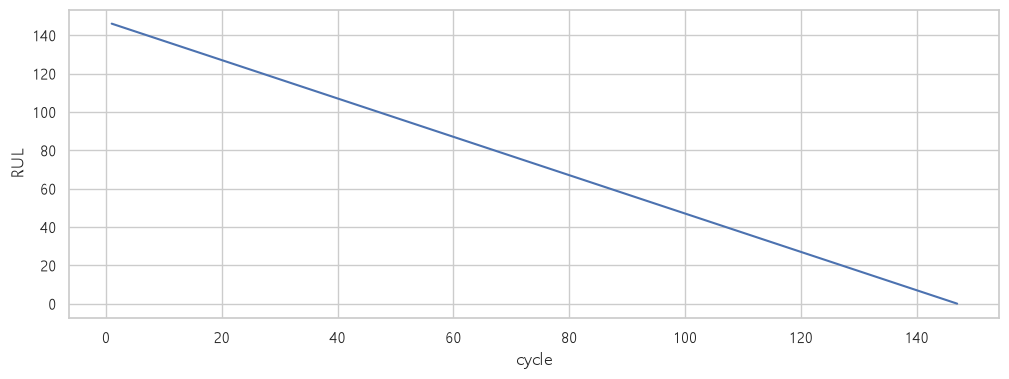

In [46]:
unit1= df[df['unit_id'] == 1]

plt.figure(figsize=(12,4))
plt.plot(unit1['cycle'], unit1['RUL'])
plt.xlabel("cycle")
plt.ylabel("RUL")
plt.show()


## 두 설비의 수명 비교
- 설비끼리는 cycle만으로 비교 불가 — 두 설비를 나란히 두고 직접 확인
- 두 설비의 최대 cycle 비교 + 같은 cycle에서 상태 차이
- 설비마다 고장까지 버티는 cycle 수가 다름을 직접 확인

### 설비별 수명 길이 구하기
groupby로 설비별 최대 cycle(=수명 길이)을 구하고 정렬


In [47]:
# 코드
life = df.groupby('unit_id')['cycle'].max() # 설비별 가장 큰 사이클 -> 오랜 수명을 가진 설비부터 짧은 수명 설비까지 한 눈에 보기
life.sort_values()


unit_id
1     147
12    149
9     161
10    163
15    164
13    168
18    172
7     173
14    177
6     177
17    177
20    179
11    187
3     197
8     198
5     198
2     202
4     205
19    205
16    215
Name: cycle, dtype: int64

### 같은 cycle에서 RUL 비교
두 설비의 같은 50 cycle 시점을 각각 골라 RUL 비교

In [53]:
# 1번 엔진의 50 CYCLE 시점
print(df[(df["unit_id"] == 1) & (df['cycle'] == 50)])

print()
# 2번 엔진의 50 CYCLE 시점
print(df[(df["unit_id"] == 2) & (df["cycle"] == 50)])

    unit_id  cycle  sensor_2  sensor_3  sensor_4  sensor_7  sensor_11  sensor_15  RUL
49        1     50   642.436  1587.969  1402.133   552.685     47.461      8.505   97

     unit_id  cycle  sensor_2  sensor_3  sensor_4  sensor_7  sensor_11  sensor_15  RUL
196        2     50   642.289  1587.573  1405.214   553.069     47.525       8.39  152


## 비교에서 얻는 교훈
- 같은 cycle이라도 설비마다 RUL이 다름
- cycle만으로는 설비끼리 직접 비교할 수 없음